In [7]:
import pystac_client
import planetary_computer
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import odc.stac
import rioxarray
import pandas as pd
import numpy as np
import time 

In [2]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

catalog

<Client id=microsoft-pc>

In [20]:
skagit_bbox = (-122.60, 48.18, -122.30, 48.45)
zoom_bbox = (-122.5, 48.24, -122.35, 48.35)

states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')
wa_gdf = states_gdf[states_gdf['NAME'] == 'Washington']
wa_gdf_clipped = gpd.clip(wa_gdf, box(*zoom_bbox))

def get_ndci_timeseries(start_date, end_date, region_bbox=skagit_bbox, focus_bbox=zoom_bbox, cloud_thres=0.30):
    """
    This function returns a DataFrame with [time, ndci_median] for the specified date range in YYYY-MM-DD.
    The region and focus area are already specified in the function, but can be changed to explore different 
    areas, minding the possible change of Sentinel-2-12a tiles.
    """
    calc_start = time.time()
    print(f"Calculating NDCI for {start_date} to {end_date}")

    ### Step 1: search and load items from Sentinel-2-12a
    all_items = (list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10UEU"}}
                           ).item_collection()) +
        list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10TET"}}
                           ).item_collection())
                )
    
    signed_items = [planetary_computer.sign(item) for item in all_items]
    bands = ["B02", "B03", "B04", "B05", "SCL"]
    s2_ds = odc.stac.load(signed_items, bands=bands, resolution=0.001, chunks={}, 
                          groupby='solar_day', bbox=focus_bbox, crs="EPSG:4326")
    s2_ds_water = s2_ds.rio.clip(wa_gdf_clipped.geometry, wa_gdf_clipped.crs, drop=False, invert=True)

    ### Step 2: filter out imagery with cloud interference
    cloud_scl = [8, 9, 10]
    cloud_fraction = s2_ds_water["SCL"].isin(cloud_scl).mean(dim=["latitude", "longitude"]).compute()
    clean_times = cloud_fraction.time.where(cloud_fraction < cloud_thres, drop=True)
    
    print(f"Timesteps before cloud filtering: {len(s2_ds_water.time.values)}")
    print(f"Timesteps after cloud filtering: {len(clean_times.values)}")

    ### Step 3: calculate NDCI
    ndci_da = (s2_ds_water["B05"] - s2_ds_water["B04"]) / (s2_ds_water["B05"] + s2_ds_water["B04"])
    water_only = s2_ds_water["SCL"] == 6
    ndci_masked_da = ndci_da.where(water_only).sel(time=clean_times).compute()

    ### Step 4: calculate NDCI median per timestep and load into DataFrame
    ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
    ndci_median_times = ndci_median.coords["time"].values
    ndci_median_df = pd.DataFrame({"time": ndci_median_times, "ndci_median": ndci_median.values})
    
    calc_time_elapsed = time.time() - calc_start
    print(f"Processing time: {calc_time_elapsed // 60:.0f}m {calc_time_elapsed % 60:.0f}s")

    return ndci_median_df

**Now let's test this function with a short duration to begin:**

In [21]:
start = "2019-01-01"
end = "2019-01-31"

get_ndci_timeseries(start, end)

Calculating NDCI for 2019-01-01 to 2019-01-31
Timesteps before cloud filtering: 11
Timesteps after cloud filtering: 3
Processing time: 0m 4s


,time,ndci_median
0,2019-01-06 19:18:01.024,-0.076167
1,2019-01-13 19:07:41.024,-0.256506
2,2019-01-16 19:17:31.024,-0.037913


**Great! Now let's calculate the NDCI for all of 2019:**

In [14]:
start = "2019-01-01"
end = "2019-12-31"

get_ndci_timeseries(start, end)

Calculating NDCI for 2019-01-01 to 2019-12-31
Timesteps before cloud filtering: 140
Timesteps after cloud filtering: 57
Processing time: 0m 35s


,time,ndci_median
0,2019-01-06 19:18:01.024,-0.076167
1,2019-01-13 19:07:41.024,-0.256506
2,2019-01-16 19:17:31.024,-0.037913
3,2019-02-05 19:16:01.024,-0.182320
4,2019-02-15 19:15:01.024,-0.006649


**Okay, now let's do the calculation for our entire desired time period:**

In [15]:
# start = "2017-01-01"
# end = "2026-03-01"

# ndci_Jan2017_to_Mar2026_df = get_ndci_timeseries(start, end)

Calculating NDCI for 2017-01-01 to 2026-03-01
Timesteps before cloud filtering: 1226
Timesteps after cloud filtering: 490
Processing time: 7m 15s


In [18]:
# ndci_Jan2017_to_Mar2026_df.to_csv("2017to2026_ndci_median.csv", index=False)

In [27]:
all_dfs = []

for year in range(2017, 2027):
    df_year = get_ndci_timeseries(f"{year}-01-01", f"{year}-12-31")
    all_dfs.append(df_year)

ndci_Jan2017_to_Mar2026_df = pd.concat(all_dfs, ignore_index=True).sort_values("time")
ndci_Jan2017_to_Mar2026_df.to_csv("2017to2026_ndci_median.csv", index=False)
print(ndci_Jan2017_to_Mar2026_df)

Calculating NDCI for 2017-01-01 to 2017-12-31
Timesteps before cloud filtering: 60
Timesteps after cloud filtering: 25
Processing time: 0m 16s
Calculating NDCI for 2018-01-01 to 2018-12-31
Timesteps before cloud filtering: 136
Timesteps after cloud filtering: 59
Processing time: 0m 35s
Calculating NDCI for 2019-01-01 to 2019-12-31
Timesteps before cloud filtering: 140
Timesteps after cloud filtering: 57
Processing time: 0m 34s
Calculating NDCI for 2020-01-01 to 2020-12-31
Timesteps before cloud filtering: 147
Timesteps after cloud filtering: 56
Processing time: 0m 35s
Calculating NDCI for 2021-01-01 to 2021-12-31
Timesteps before cloud filtering: 135
Timesteps after cloud filtering: 60
Processing time: 0m 35s
Calculating NDCI for 2022-01-01 to 2022-12-31
Timesteps before cloud filtering: 143
Timesteps after cloud filtering: 55
Processing time: 0m 43s
Calculating NDCI for 2023-01-01 to 2023-12-31
Timesteps before cloud filtering: 145
Timesteps after cloud filtering: 56
Processing time: 

**Let's inspect the data and see how it looks:**

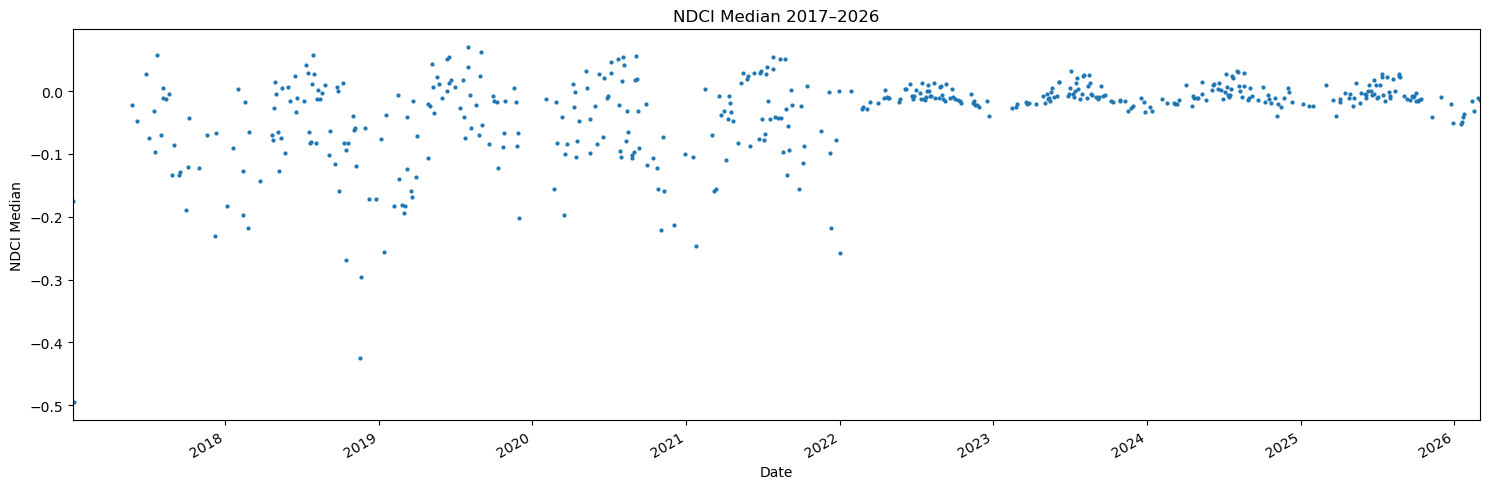

In [29]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ndci_Jan2017_to_Mar2026_df['time'], ndci_Jan2017_to_Mar2026_df['ndci_median'], marker='o', markersize=2, linewidth=0.8, ls='')

ax.set_xlim(ndci_Jan2017_to_Mar2026_df['time'].min(), ndci_Jan2017_to_Mar2026_df['time'].max())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.set_title("NDCI Median 2017–2026")
ax.set_xlabel("Date")
ax.set_ylabel("NDCI Median")
plt.tight_layout()

# #notes
# # for stac: ## 32610 so we can specify meters for resolution

In [44]:
skagit_bbox = (-122.60, 48.18, -122.30, 48.45)
zoom_bbox = (-122.5, 48.24, -122.35, 48.35)

states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')
wa_gdf = states_gdf[states_gdf['NAME'] == 'Washington']
wa_gdf_clipped = gpd.clip(wa_gdf, box(*zoom_bbox))

def get_ndci_timeseries(start_date, end_date, region_bbox=skagit_bbox, focus_bbox=zoom_bbox, cloud_thres=0.30):
    """
    This function returns a DataFrame with [time, ndci_median] for the specified date range in YYYY-MM-DD.
    The region and focus area are already specified in the function, but can be changed to explore different 
    areas, minding the possible change of Sentinel-2-12a tiles.
    """
    calc_start = time.time()
    print(f"Calculating NDCI for {start_date} to {end_date}")

    ### Step 1: search and load items from Sentinel-2-12a
    all_items = (list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10UEU"}}
                           ).item_collection()) +
        list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10TET"}}
                           ).item_collection())
                )
    
    signed_items = [planetary_computer.sign(item) for item in all_items]
    bands = ["B02", "B03", "B04", "B05", "SCL"]
    s2_ds = odc.stac.load(signed_items, bands=bands, resolution=0.001, chunks={}, 
                          groupby='solar_day', bbox=focus_bbox, crs="EPSG:4326")

    s2_ds_water = s2_ds.rio.clip(wa_gdf_clipped.geometry, wa_gdf_clipped.crs, drop=False, invert=True)

    ### Step 2: filter out imagery with cloud interference
    cloud_scl = [8, 9, 10]
    cloud_fraction = s2_ds_water["SCL"].isin(cloud_scl).mean(dim=["latitude", "longitude"]).compute()
    clean_times = cloud_fraction.time.where(cloud_fraction < cloud_thres, drop=True)
    
    print(f"Timesteps before cloud filtering: {len(s2_ds_water.time.values)}")
    print(f"Timesteps after cloud filtering: {len(clean_times.values)}")

    ### Step 3: calculate NDCI
    # Check processing baseline and apply offset correction for pre-baseline 4.00 data
    baseline = float(signed_items[0].properties.get("s2:processing_baseline", "0"))
    print(f"Processing baseline: {baseline}")
    
    B05 = s2_ds_water["B05"] - (1000 if baseline < 4.0 else 0)
    B04 = s2_ds_water["B04"] - (1000 if baseline < 4.0 else 0)
    
    ndci_da = (B05 - B04) / (B05 + B04)
    water_only = s2_ds_water["SCL"] == 6
    
    # Filter out timesteps with too few water pixels
    water_pixel_counts = water_only.sel(time=clean_times).sum(dim=["latitude", "longitude"]).compute()
    valid_times = water_pixel_counts.time.where(water_pixel_counts > 1000, drop=True)
    print(f"Timesteps after water pixel filtering: {len(valid_times.values)}")
    
    ndci_masked_da = ndci_da.where(water_only).sel(time=valid_times).compute()
    
    ### Step 4: calculate NDCI median per timestep and load into DataFrame
    ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
    ndci_median_times = ndci_median.coords["time"].values
    ndci_median_df = pd.DataFrame({
        "time": ndci_median_times,
        "ndci_median": ndci_median.values
    }).dropna(subset=["ndci_median"])  # safety net

    # ### Step 4: calculate NDCI median per timestep and load into DataFrame
    # ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
    # ndci_median_times = ndci_median.coords["time"].values
    # ndci_median_df = pd.DataFrame({"time": ndci_median_times, "ndci_median": ndci_median.values})
    
    calc_time_elapsed = time.time() - calc_start
    print(f"Processing time: {calc_time_elapsed // 60:.0f}m {calc_time_elapsed % 60:.0f}s")

    return ndci_median_df

In [46]:
all_dfs = []

for year in range(2022, 2026):
    df_year = get_ndci_timeseries(f"{year}-01-01", f"{year}-12-31")
    all_dfs.append(df_year)

ndci_Jan2022_to_Mar2026_df = pd.concat(all_dfs, ignore_index=True).sort_values("time")
ndci_Jan2022_to_Mar2026_df.to_csv("2022to2026_ndci_median.csv", index=False) # ACTUALLY 2018!!
print(ndci_Jan2022_to_Mar2026_df)

Calculating NDCI for 2022-01-01 to 2022-12-31
Timesteps before cloud filtering: 143
Timesteps after cloud filtering: 55
Processing baseline: 4.0
Timesteps after water pixel filtering: 55
Processing time: 0m 48s
Calculating NDCI for 2023-01-01 to 2023-12-31
Timesteps before cloud filtering: 145
Timesteps after cloud filtering: 56
Processing baseline: 5.1
Timesteps after water pixel filtering: 56
Processing time: 0m 59s
Calculating NDCI for 2024-01-01 to 2024-12-31
Timesteps before cloud filtering: 143
Timesteps after cloud filtering: 58
Processing baseline: 5.11
Timesteps after water pixel filtering: 58
Processing time: 0m 36s
Calculating NDCI for 2025-01-01 to 2025-12-31
Timesteps before cloud filtering: 152
Timesteps after cloud filtering: 57
Processing baseline: 5.11
Timesteps after water pixel filtering: 57
Processing time: 0m 44s
                       time  ndci_median
0   2022-01-27 19:06:41.024    -0.000539
1   2022-02-21 19:04:09.024    -0.028642
2   2022-02-24 19:13:49.024    

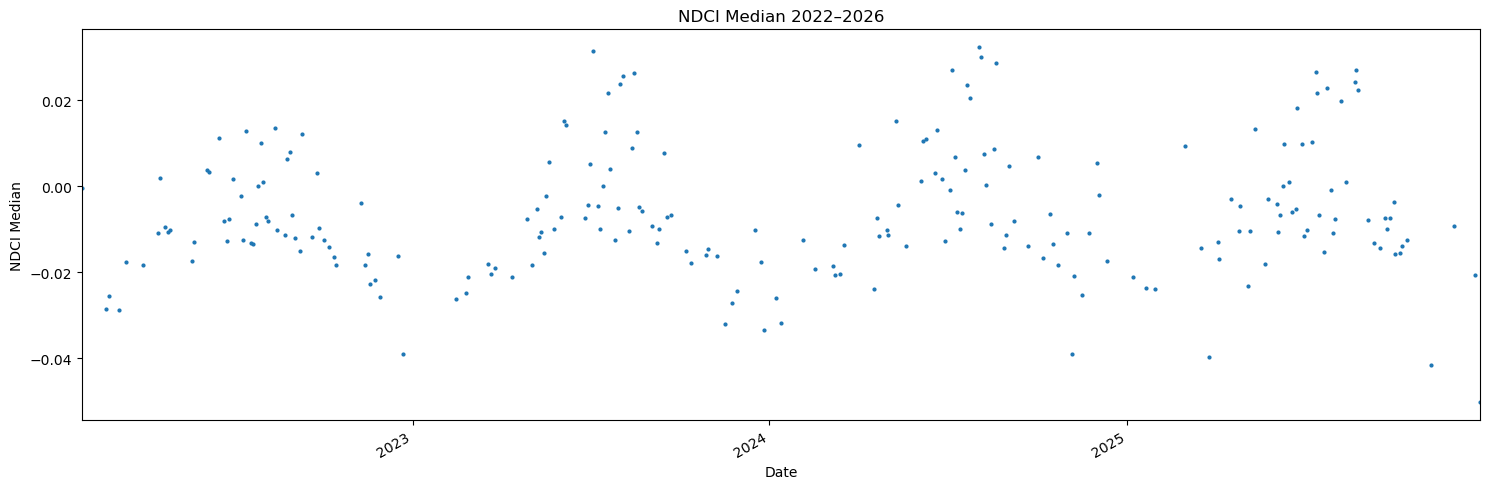

In [47]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ndci_Jan2022_to_Mar2026_df['time'], ndci_Jan2022_to_Mar2026_df['ndci_median'], marker='o', markersize=2, linewidth=0.8, ls='')

ax.set_xlim(ndci_Jan2022_to_Mar2026_df['time'].min(), ndci_Jan2022_to_Mar2026_df['time'].max())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.set_title("NDCI Median 2022–2026")
ax.set_xlabel("Date")
ax.set_ylabel("NDCI Median")
plt.tight_layout()